# Pearls AQI Predictor - Exploratory Data Analysis

This notebook explores the raw and processed data for the AQI prediction system.

**Data Sources:**
- Raw Data: `data/raw/historical_data.csv` (from Open-Meteo API)
- Processed Data: `data/processed/features.csv` (engineered features)

**Analysis Sections:**
1. Raw Data Exploration
2. Processed Features Analysis
3. Distribution Analysis
4. Correlation Analysis
5. Time Series Patterns
6. AQI Categories Distribution

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Raw Data Exploration

In [2]:
# Load raw data
raw_df = pd.read_csv('../data/raw/historical_data.csv')
raw_df['time'] = pd.to_datetime(raw_df['time'])

print("="*60)
print("RAW DATA OVERVIEW")
print("="*60)
print(f"\nShape: {raw_df.shape}")
print(f"Date Range: {raw_df['time'].min()} to {raw_df['time'].max()}")
print(f"Duration: {(raw_df['time'].max() - raw_df['time'].min()).days} days")
print(f"\nColumns: {list(raw_df.columns)}")
print(f"\nData Types:\n{raw_df.dtypes}")
print(f"\nMemory Usage: {raw_df.memory_usage(deep=True).sum() / 1024:.2f} KB")

RAW DATA OVERVIEW

Shape: (26304, 10)
Date Range: 2023-01-31 00:00:00 to 2026-01-30 23:00:00
Duration: 1095 days

Columns: ['time', 'pm10', 'pm2_5', 'us_aqi', 'european_aqi', 'temperature_2m', 'relative_humidity_2m', 'wind_speed_10m', 'wind_direction_10m', 'precipitation']

Data Types:
time                    datetime64[ns]
pm10                           float64
pm2_5                          float64
us_aqi                           int64
european_aqi                     int64
temperature_2m                 float64
relative_humidity_2m             int64
wind_speed_10m                 float64
wind_direction_10m               int64
precipitation                  float64
dtype: object

Memory Usage: 2055.13 KB


In [3]:
# Basic statistics
print("\n" + "="*60)
print("STATISTICAL SUMMARY")
print("="*60)
raw_df.describe()


STATISTICAL SUMMARY


,time,pm10,pm2_5,us_aqi,european_aqi,temperature_2m,relative_humidity_2m,wind_speed_10m,wind_direction_10m,precipitation
count,26304,26304.000000,26304.000000,26304.000000,26304.000000,26304.000000,26304.000000,26304.000000,26304.000000,26304.000000
mean,2024-07-31 23:30:00,62.796860,29.103901,87.981334,65.880170,26.514903,65.824932,14.601908,217.358577,0.027992
min,2023-01-31 00:00:00,3.900000,3.800000,35.000000,18.000000,9.200000,5.000000,0.000000,1.000000,0.000000
25%,2023-10-31 23:45:00,39.200000,19.000000,68.000000,60.000000,23.775000,52.000000,9.100000,209.000000,0.000000
50%,2024-07-31 23:30:00,53.700000,24.700000,80.000000,66.000000,27.400000,70.000000,13.400000,249.000000,0.000000
75%,2025-05-01 23:15:00,75.000000,34.100000,101.000000,74.000000,29.800000,83.000000,19.200000,271.000000,0.000000
max,2026-01-30 23:00:00,497.300000,339.000000,297.000000,170.000000,41.500000,100.000000,46.600000,360.000000,16.500000
std,NaN,38.201674,16.718784,29.250568,17.351077,4.807757,21.472642,7.248499,92.773589,0.335253


In [4]:
# Missing values
print("\n" + "="*60)
print("MISSING VALUES ANALYSIS")
print("="*60)
missing = raw_df.isnull().sum()
missing_pct = (missing / len(raw_df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage': missing_pct
})
print(missing_df[missing_df['Missing Count'] > 0])


MISSING VALUES ANALYSIS
Empty DataFrame
Columns: [Missing Count, Percentage]
Index: []


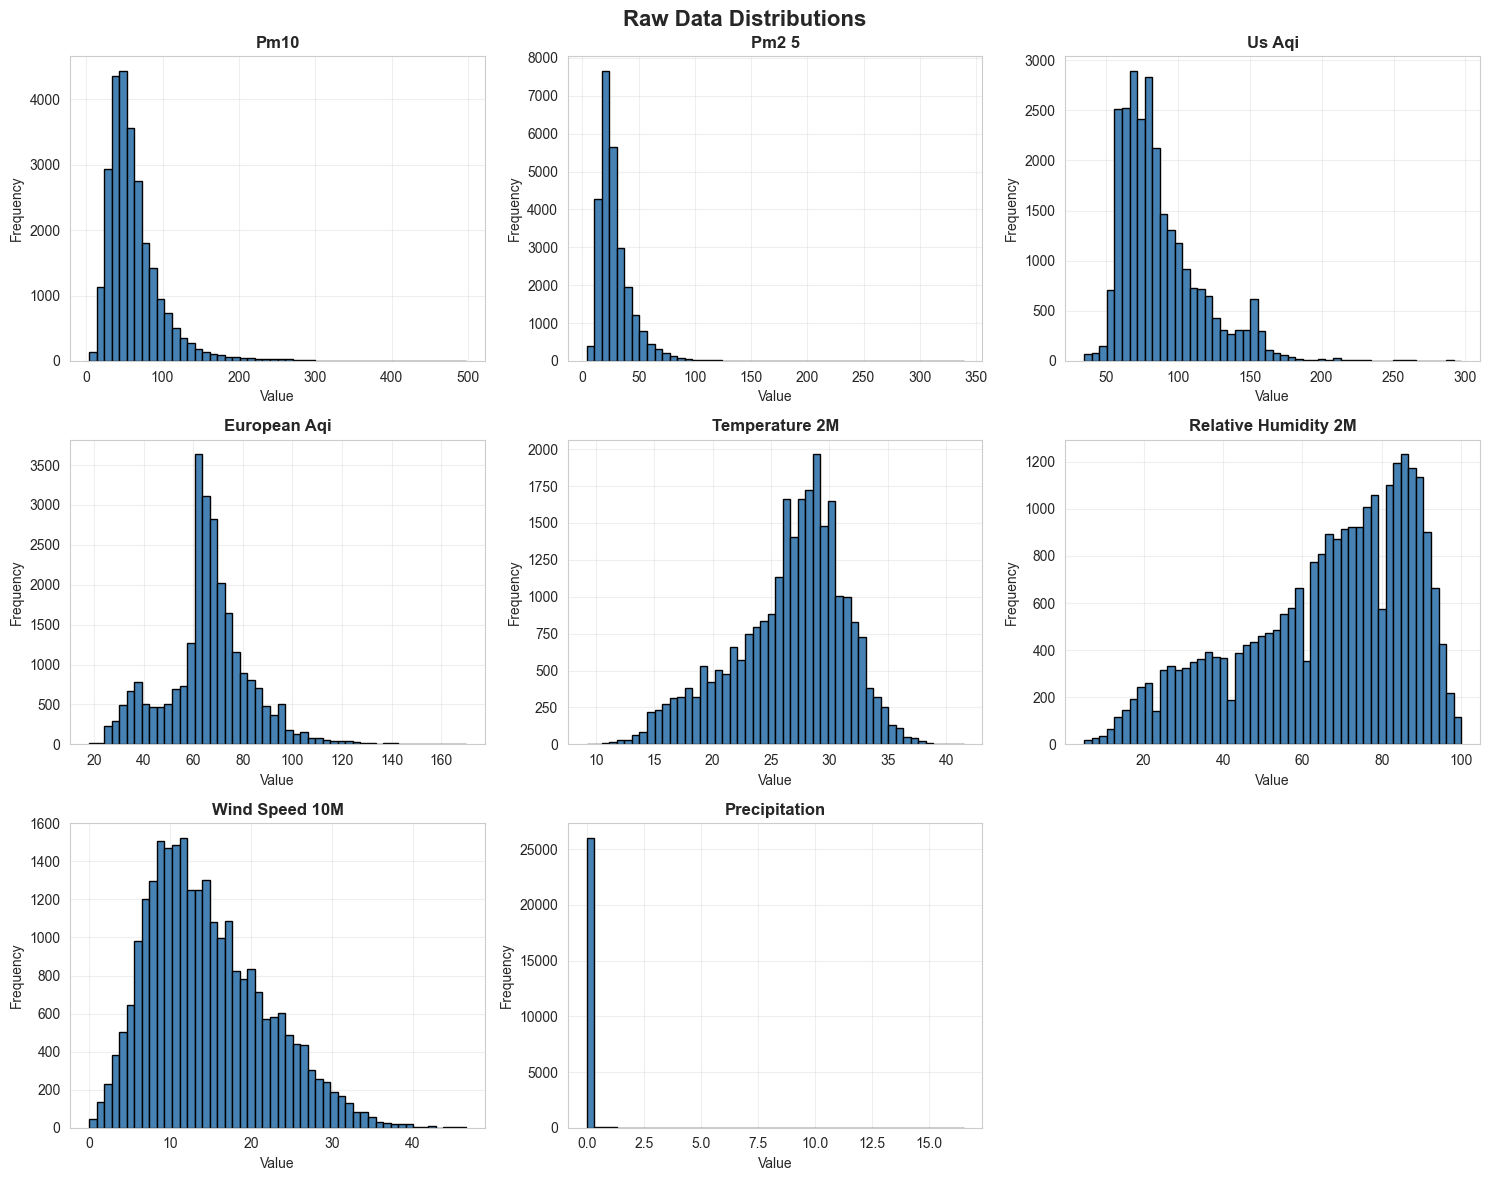

In [5]:
# Visualize raw data distributions
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Raw Data Distributions', fontsize=16, fontweight='bold')

columns = ['pm10', 'pm2_5', 'us_aqi', 'european_aqi', 'temperature_2m', 
           'relative_humidity_2m', 'wind_speed_10m', 'precipitation']

for idx, col in enumerate(columns):
    ax = axes[idx // 3, idx % 3]
    raw_df[col].hist(bins=50, ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(f'{col.replace("_", " ").title()}', fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.grid(alpha=0.3)

# Remove empty subplot
fig.delaxes(axes[2, 2])

plt.tight_layout()
plt.show()

In [6]:
# Time series plot of AQI
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=raw_df['time'],
    y=raw_df['us_aqi'],
    mode='lines',
    name='US AQI',
    line=dict(color='#1E88E5', width=1.5)
))

# Add AQI category bands
fig.add_hrect(y0=0, y1=50, fillcolor="green", opacity=0.1, line_width=0, annotation_text="Good")
fig.add_hrect(y0=50, y1=100, fillcolor="yellow", opacity=0.1, line_width=0, annotation_text="Moderate")
fig.add_hrect(y0=100, y1=150, fillcolor="orange", opacity=0.1, line_width=0, annotation_text="Unhealthy for Sensitive")
fig.add_hrect(y0=150, y1=200, fillcolor="red", opacity=0.1, line_width=0, annotation_text="Unhealthy")

fig.update_layout(
    title='Historical US AQI Trend (Raw Data)',
    xaxis_title='Date',
    yaxis_title='US AQI',
    height=500,
    hovermode='x unified'
)

fig.show()

## 2. Processed Features Analysis

In [7]:
# Load processed features
feat_df = pd.read_csv('../data/processed/features.csv')
feat_df['time'] = pd.to_datetime(feat_df['time'])

print("="*60)
print("PROCESSED FEATURES OVERVIEW")
print("="*60)
print(f"\nShape: {feat_df.shape}")
print(f"Date Range: {feat_df['time'].min()} to {feat_df['time'].max()}")
print(f"\nEngineered Features Count: {feat_df.shape[1] - raw_df.shape[1]}")
print(f"\nNew Features Created:")
new_features = [col for col in feat_df.columns if col not in raw_df.columns]
for feat in new_features:
    print(f"  - {feat}")
print(f"\nMemory Usage: {feat_df.memory_usage(deep=True).sum() / 1024:.2f} KB")

PROCESSED FEATURES OVERVIEW

Shape: (26280, 32)
Date Range: 2023-02-01 00:00:00 to 2026-01-30 23:00:00

Engineered Features Count: 22

New Features Created:
  - us_aqi_lag_1h
  - us_aqi_lag_2h
  - us_aqi_lag_3h
  - us_aqi_lag_24h
  - us_aqi_rolling_mean_3h
  - us_aqi_rolling_mean_24h
  - us_aqi_rolling_std_24h
  - wind_u_component
  - wind_v_component
  - hour_sin
  - hour_cos
  - day_of_week_sin
  - day_of_week_cos
  - month_sin
  - month_cos
  - day_of_week_num
  - is_weekend
  - hour_of_day
  - is_rush_hour
  - season
  - temp_humidity_interaction
  - wind_precip_interaction

Memory Usage: 6570.13 KB


In [8]:
# Compare before and after feature engineering
print("\n" + "="*60)
print("DATA COMPARISON: RAW vs PROCESSED")
print("="*60)
print(f"\nRaw Data:")
print(f"  Records: {len(raw_df):,}")
print(f"  Features: {raw_df.shape[1]}")
print(f"  Size: {raw_df.memory_usage(deep=True).sum() / 1024:.2f} KB")
print(f"\nProcessed Data:")
print(f"  Records: {len(feat_df):,}")
print(f"  Features: {feat_df.shape[1]}")
print(f"  Size: {feat_df.memory_usage(deep=True).sum() / 1024:.2f} KB")
print(f"\nRecords Removed (due to lag/rolling features): {len(raw_df) - len(feat_df):,}")


DATA COMPARISON: RAW vs PROCESSED

Raw Data:
  Records: 26,304
  Features: 10
  Size: 2055.13 KB

Processed Data:
  Records: 26,280
  Features: 32
  Size: 6570.13 KB

Records Removed (due to lag/rolling features): 24


In [9]:
# Lag features analysis
lag_features = [col for col in feat_df.columns if 'lag' in col.lower()]

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=['Current AQI vs 1h Lag', 'Current AQI vs 2h Lag', 
                    'Current AQI vs 3h Lag', 'Current AQI vs 24h Lag']
)

lag_cols = ['us_aqi_lag_1h', 'us_aqi_lag_2h', 'us_aqi_lag_3h', 'us_aqi_lag_24h']
positions = [(1,1), (1,2), (2,1), (2,2)]

for lag_col, (row, col) in zip(lag_cols, positions):
    fig.add_trace(
        go.Scatter(
            x=feat_df['us_aqi'],
            y=feat_df[lag_col],
            mode='markers',
            marker=dict(size=3, opacity=0.5),
            name=lag_col
        ),
        row=row, col=col
    )
    
    # Add diagonal line
    fig.add_trace(
        go.Scatter(
            x=[0, feat_df['us_aqi'].max()],
            y=[0, feat_df['us_aqi'].max()],
            mode='lines',
            line=dict(color='red', dash='dash'),
            showlegend=False
        ),
        row=row, col=col
    )

fig.update_layout(
    title_text='Lag Features Correlation with Current AQI',
    height=700,
    showlegend=False
)

fig.show()

In [10]:
# Rolling statistics visualization
sample_df = feat_df.tail(24*7)  # Last 7 days

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=sample_df['time'],
    y=sample_df['us_aqi'],
    mode='lines',
    name='Current AQI',
    line=dict(color='blue', width=2)
))

fig.add_trace(go.Scatter(
    x=sample_df['time'],
    y=sample_df['us_aqi_rolling_mean_3h'],
    mode='lines',
    name='3h Rolling Mean',
    line=dict(color='green', width=1.5, dash='dot')
))

fig.add_trace(go.Scatter(
    x=sample_df['time'],
    y=sample_df['us_aqi_rolling_mean_24h'],
    mode='lines',
    name='24h Rolling Mean',
    line=dict(color='orange', width=1.5, dash='dash')
))

fig.update_layout(
    title='Current AQI vs Rolling Averages (Last 7 Days)',
    xaxis_title='Date',
    yaxis_title='AQI',
    height=500,
    hovermode='x unified'
)

fig.show()

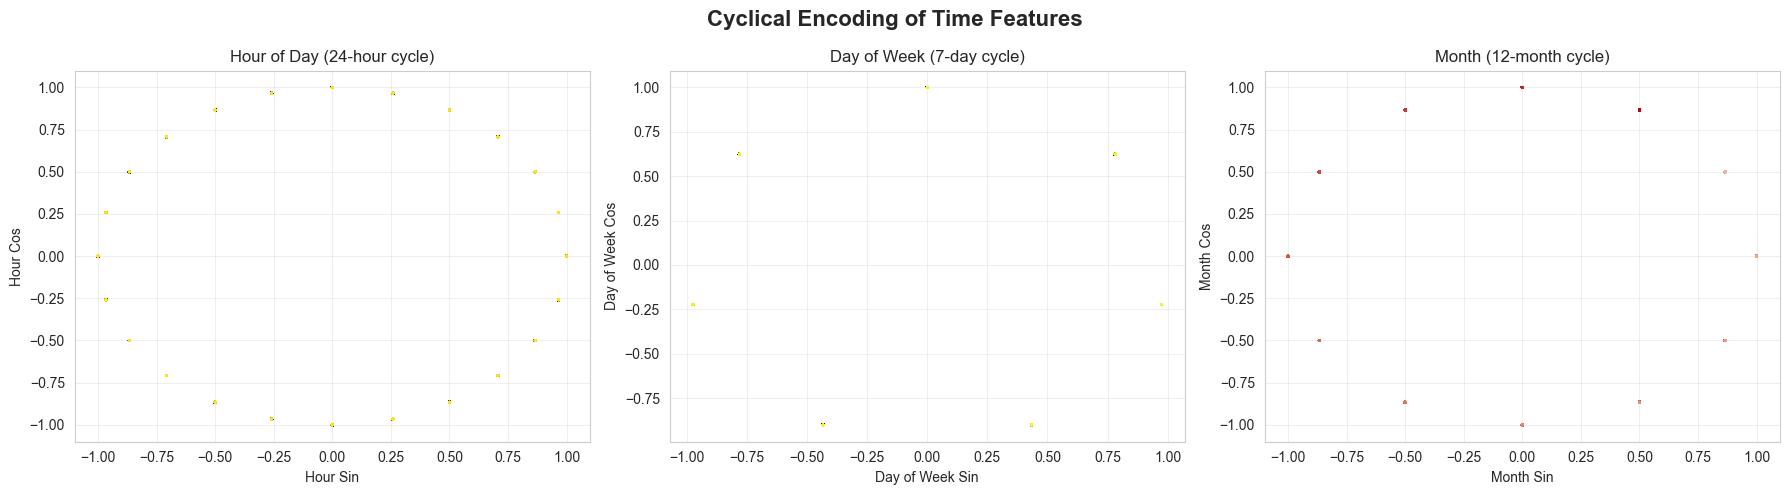

In [11]:
# Cyclical features visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Cyclical Encoding of Time Features', fontsize=16, fontweight='bold')

# Hour
scatter1 = axes[0].scatter(feat_df['hour_sin'], feat_df['hour_cos'], 
                           c=range(len(feat_df)), cmap='viridis', s=1, alpha=0.5)
axes[0].set_xlabel('Hour Sin')
axes[0].set_ylabel('Hour Cos')
axes[0].set_title('Hour of Day (24-hour cycle)')
axes[0].grid(alpha=0.3)

# Day of Week
scatter2 = axes[1].scatter(feat_df['day_of_week_sin'], feat_df['day_of_week_cos'], 
                           c=range(len(feat_df)), cmap='plasma', s=1, alpha=0.5)
axes[1].set_xlabel('Day of Week Sin')
axes[1].set_ylabel('Day of Week Cos')
axes[1].set_title('Day of Week (7-day cycle)')
axes[1].grid(alpha=0.3)

# Month
scatter3 = axes[2].scatter(feat_df['month_sin'], feat_df['month_cos'], 
                           c=range(len(feat_df)), cmap='coolwarm', s=1, alpha=0.5)
axes[2].set_xlabel('Month Sin')
axes[2].set_ylabel('Month Cos')
axes[2].set_title('Month (12-month cycle)')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Correlation Analysis

In [12]:
# Select numeric features for correlation
numeric_cols = feat_df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col != 'us_aqi']  # Exclude target

# Calculate correlation with target
correlations = feat_df[numeric_cols + ['us_aqi']].corr()['us_aqi'].sort_values(ascending=False)

print("="*60)
print("TOP 15 FEATURES CORRELATED WITH US AQI")
print("="*60)
print(correlations[1:16])  # Exclude self-correlation

# Visualize top correlations
top_features = correlations[1:16]

fig = go.Figure(go.Bar(
    x=top_features.values,
    y=top_features.index,
    orientation='h',
    marker=dict(
        color=top_features.values,
        colorscale='RdYlGn',
        reversescale=True
    )
))

fig.update_layout(
    title='Top 15 Features Correlated with US AQI',
    xaxis_title='Correlation Coefficient',
    yaxis_title='Feature',
    height=600
)

fig.show()

TOP 15 FEATURES CORRELATED WITH US AQI
us_aqi_rolling_mean_3h     0.991906
us_aqi_lag_1h              0.989659
us_aqi_lag_2h              0.968887
us_aqi_lag_3h              0.945452
us_aqi_rolling_mean_24h    0.902643
us_aqi_lag_24h             0.758503
pm2_5                      0.728550
european_aqi               0.724345
us_aqi_rolling_std_24h     0.460072
month_cos                  0.448076
pm10                       0.346637
month_sin                  0.149942
hour_of_day                0.056885
is_rush_hour               0.039076
day_of_week_cos            0.029391
Name: us_aqi, dtype: float64


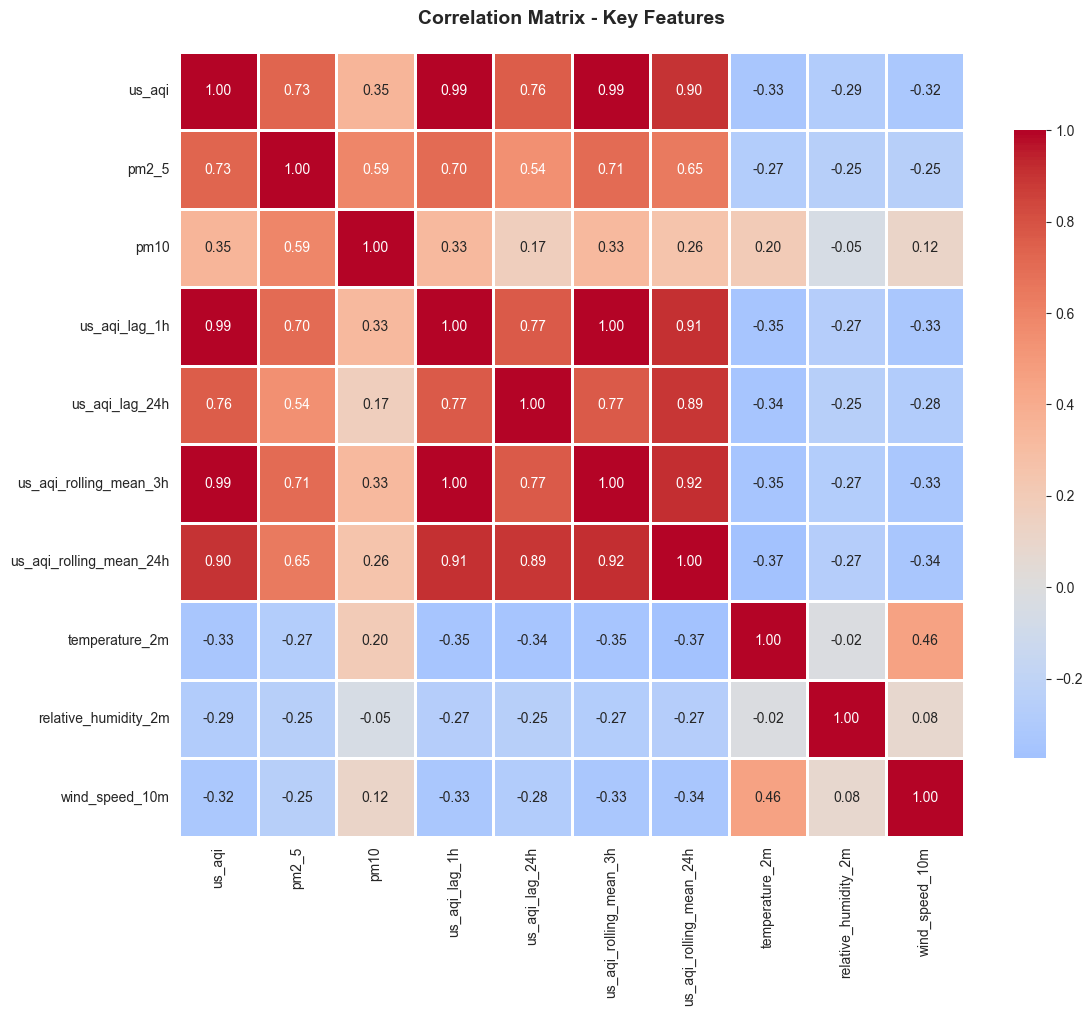

In [13]:
# Full correlation heatmap for selected features
key_features = ['us_aqi', 'pm2_5', 'pm10', 'us_aqi_lag_1h', 'us_aqi_lag_24h',
                'us_aqi_rolling_mean_3h', 'us_aqi_rolling_mean_24h',
                'temperature_2m', 'relative_humidity_2m', 'wind_speed_10m']

corr_matrix = feat_df[key_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - Key Features', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

## 4. AQI Categories Distribution

In [14]:
# Define AQI categories
def categorize_aqi(aqi):
    if aqi <= 50:
        return 'Good'
    elif aqi <= 100:
        return 'Moderate'
    elif aqi <= 150:
        return 'Unhealthy for Sensitive'
    elif aqi <= 200:
        return 'Unhealthy'
    elif aqi <= 300:
        return 'Very Unhealthy'
    else:
        return 'Hazardous'

raw_df['aqi_category'] = raw_df['us_aqi'].apply(categorize_aqi)
category_counts = raw_df['aqi_category'].value_counts()

print("="*60)
print("AQI CATEGORY DISTRIBUTION")
print("="*60)
print(category_counts)
print(f"\nPercentages:")
print((category_counts / len(raw_df) * 100).round(2))

AQI CATEGORY DISTRIBUTION
aqi_category
Moderate                   19399
Unhealthy for Sensitive     5197
Unhealthy                   1261
Good                         301
Very Unhealthy               146
Name: count, dtype: int64

Percentages:
aqi_category
Moderate                   73.75
Unhealthy for Sensitive    19.76
Unhealthy                   4.79
Good                        1.14
Very Unhealthy              0.56
Name: count, dtype: float64


In [15]:
# Visualize AQI categories
colors = {
    'Good': '#00E400',
    'Moderate': '#FFFF00',
    'Unhealthy for Sensitive': '#FF7E00',
    'Unhealthy': '#FF0000',
    'Very Unhealthy': '#8F3F97',
    'Hazardous': '#7E0023'
}

category_order = ['Good', 'Moderate', 'Unhealthy for Sensitive', 
                  'Unhealthy', 'Very Unhealthy', 'Hazardous']

fig = px.pie(
    values=category_counts.values,
    names=category_counts.index,
    title='Distribution of AQI Categories',
    color=category_counts.index,
    color_discrete_map=colors,
    hole=0.3
)

fig.update_traces(textposition='inside', textinfo='percent+label')
fig.update_layout(height=600)
fig.show()

## 5. Time-Based Patterns

In [16]:
# Extract time components
raw_df['hour'] = raw_df['time'].dt.hour
raw_df['day_of_week'] = raw_df['time'].dt.day_name()
raw_df['month'] = raw_df['time'].dt.month_name()

# Hourly pattern
hourly_avg = raw_df.groupby('hour')['us_aqi'].agg(['mean', 'std']).reset_index()

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=hourly_avg['hour'],
    y=hourly_avg['mean'],
    mode='lines+markers',
    name='Mean AQI',
    line=dict(color='blue', width=2),
    error_y=dict(
        type='data',
        array=hourly_avg['std'],
        visible=True
    )
))

fig.update_layout(
    title='Average AQI by Hour of Day',
    xaxis_title='Hour',
    yaxis_title='Average US AQI',
    height=500,
    xaxis=dict(tickmode='linear', tick0=0, dtick=1)
)

fig.show()

In [17]:
# Day of week pattern
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_avg = raw_df.groupby('day_of_week')['us_aqi'].mean().reindex(day_order)

fig = px.bar(
    x=dow_avg.index,
    y=dow_avg.values,
    title='Average AQI by Day of Week',
    labels={'x': 'Day of Week', 'y': 'Average US AQI'},
    color=dow_avg.values,
    color_continuous_scale='RdYlGn_r'
)

fig.update_layout(height=500, showlegend=False)
fig.show()

## 6. Summary Statistics

In [18]:
# Overall summary
print("="*60)
print("DATA ANALYSIS SUMMARY")
print("="*60)

print(f"\n📊 DATA VOLUME:")
print(f"  Raw Records: {len(raw_df):,}")
print(f"  Processed Records: {len(feat_df):,}")
print(f"  Features Created: {len(new_features)}")

print(f"\n📈 AQI STATISTICS:")
print(f"  Mean AQI: {raw_df['us_aqi'].mean():.2f}")
print(f"  Median AQI: {raw_df['us_aqi'].median():.2f}")
print(f"  Min AQI: {raw_df['us_aqi'].min():.0f}")
print(f"  Max AQI: {raw_df['us_aqi'].max():.0f}")
print(f"  Std Dev: {raw_df['us_aqi'].std():.2f}")

print(f"\n🌡️ WEATHER STATISTICS:")
print(f"  Avg Temperature: {raw_df['temperature_2m'].mean():.1f}°C")
print(f"  Avg Humidity: {raw_df['relative_humidity_2m'].mean():.1f}%")
print(f"  Avg Wind Speed: {raw_df['wind_speed_10m'].mean():.1f} km/h")

print(f"\n🔍 TOP CORRELATED FEATURES:")
for feat, corr in correlations[1:6].items():
    print(f"  {feat}: {corr:.3f}")

print(f"\n✅ Data is ready for model training!")
print("="*60)

DATA ANALYSIS SUMMARY

📊 DATA VOLUME:
  Raw Records: 26,304
  Processed Records: 26,280
  Features Created: 22

📈 AQI STATISTICS:
  Mean AQI: 87.98
  Median AQI: 80.00
  Min AQI: 35
  Max AQI: 297
  Std Dev: 29.25

🌡️ WEATHER STATISTICS:
  Avg Temperature: 26.5°C
  Avg Humidity: 65.8%
  Avg Wind Speed: 14.6 km/h

🔍 TOP CORRELATED FEATURES:
  us_aqi_rolling_mean_3h: 0.992
  us_aqi_lag_1h: 0.990
  us_aqi_lag_2h: 0.969
  us_aqi_lag_3h: 0.945
  us_aqi_rolling_mean_24h: 0.903

✅ Data is ready for model training!
